In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# ── ACL/EMNLP single-column style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size":        8,
    "axes.titlesize":   8,
    "axes.labelsize":   8,
    "legend.fontsize":  7,
    "legend.title_fontsize": 7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.linewidth":   0.7,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "lines.linewidth":  1,
    "figure.dpi":       200,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

In [2]:
import matplotlib.ticker as ticker
import pandas as pd
import wandb

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
ENTITY  = "behzadshomali"
PROJECT = "nemotron_MATH_PartialMTP_Gating"

# run_id -> legend label
RUNS = {
    "40ew92o7": "Low",
    "t62gpsx1": "Medium",
    "7bwfu8fx": "High",
}

METRIC   = "train grad norm last"
STEP_COL = "_step"

# Colors / linestyles distinguish the three runs (grayscale-safe)
COLORS_RUNS = plt.cm.Set2.colors
LINESTYLES  = ["-", "--", "-."]
LINESTYLES  = ["-", "-", "-"]

In [3]:
# ── Fetch "train grad norm last" history for each run ───────────────────────
api = wandb.Api()
histories = {}
for run_id in RUNS:
    run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
    h = run.history(keys=[METRIC], pandas=True)
    h = h.sort_values(STEP_COL).reset_index(drop=True)
    histories[run_id] = h

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/behzad_shomali/.netrc.


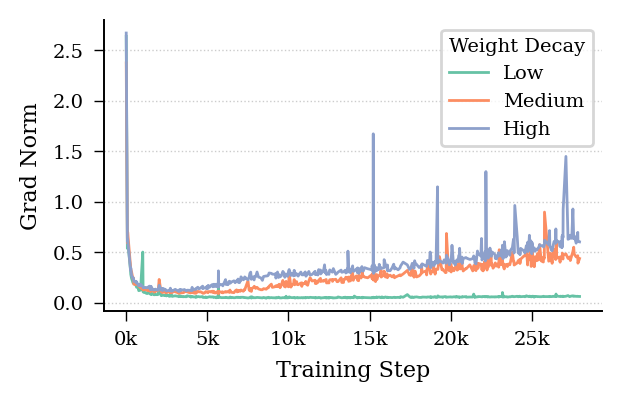

In [4]:
# ── Overlay plot: train grad norm last ──────────────────────────────────────
# Optional smoothing for the spiky grad-norm trace (1 = raw, faithful).
SMOOTH = 1

fig, ax = plt.subplots(figsize=(3,1.9))  # single-column ACL width

for i, (run_id, label) in enumerate(RUNS.items()):
    h     = histories[run_id]
    vals  = h[METRIC].dropna()
    steps = h.loc[vals.index, STEP_COL]
    y     = vals.rolling(SMOOTH, min_periods=1).mean() if SMOOTH > 1 else vals

    ax.plot(
        steps,
        y.values,
        label=label,
        color=COLORS_RUNS[(i+0)],
        linestyle=LINESTYLES[i % len(LINESTYLES)],
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#aaaaaa")
ax.set_axisbelow(True)

ax.set_xlabel("Training Step")
ax.set_ylabel("Grad Norm")
# ax.set_title("Gradient Norm")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x / 1000)}k"))
ax.legend(title="Weight Decay", frameon=True, framealpha=0.8, edgecolor="#cccccc", loc="best")

fig.tight_layout(pad=0.4)
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/grad_norm_last.pdf")
plt.show()

# Lipschitz factor

In [5]:
import os
import sys
import math
import tempfile
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm

WORKSPACE_ROOT = Path('/raid/s3/opengptx/behzad_shomali')
MODALITIES_SRC = WORKSPACE_ROOT / 'modalities' / 'src'
if str(MODALITIES_SRC) not in sys.path:
    sys.path.insert(0, str(MODALITIES_SRC))

from modalities.evaluation.olmes_evaluator import load_modalities_model

/raid/s3/opengptx/behzad_shomali/modalities/olmes/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/modalities/olmes/.venv/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Skipping import of cpp extensions due to incompatible torch version 2.8.0+cu128 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
2026-06-26:18:52:26,594 INFO     [rouge_scorer.py:83] Using default tokenizer.


In [6]:
import pandas as pd

# ── Product-of-spectral-norms Lipschitz upper bound ─────────────────────────
# The Lipschitz constant of the network is upper-bounded by the product of the
# spectral norms (largest singular value) of each linear weight matrix along
# the forward path. We estimate each spectral norm with power iteration (cheap,
# GPU-friendly) and accumulate the bound in log-space to avoid overflow.

@torch.no_grad()
def spectral_norm_power_iter(W, n_iters=100, tol=1e-7):
    """Largest singular value of a 2D weight matrix via power iteration."""
    W = W.detach().float()
    m, n = W.shape
    v = torch.randn(n, device=W.device)
    v /= v.norm() + 1e-12
    sigma_prev = 0.0
    for _ in range(n_iters):
        u = W @ v
        u = u / (u.norm() + 1e-12)
        v = W.t() @ u
        v = v / (v.norm() + 1e-12)
        sigma = (u @ (W @ v)).item()
        if abs(sigma - sigma_prev) < tol:
            break
        sigma_prev = sigma
    return (u @ (W @ v)).item()

# rows = []
# log_product = 0.0
# for name, module in model.named_modules():
#     if "halt_block" in name:
#         continue
#     W = getattr(module, "weight", None)
#     if W is None or W.dim() != 2:
#         continue
#     sigma = spectral_norm_power_iter(W.to(DEVICE))
#     log_product += math.log(max(sigma, 1e-30))
#     rows.append((name, type(module).__name__, tuple(W.shape), sigma))

# df_lip = pd.DataFrame(rows, columns=["layer", "module_type", "shape", "spectral_norm"])
# df_lip = df_lip.sort_values("spectral_norm", ascending=False).reset_index(drop=True)

# print(f"Linear weight matrices included : {len(df_lip)}")
# print(f"Sum of log spectral norms       : {log_product:.4f}")
# print(f"Lipschitz upper bound (product) : {math.exp(log_product):.4e}")
# print(f"Geometric mean spectral norm    : {math.exp(log_product / max(len(df_lip),1)):.4f}")
# print("\nTop-30 layers by spectral norm:")
# df_lip.head(30)


In [7]:
PREFIX = "/raid/s3/opengptx/behzad_shomali/checkpoints/"
d = {
    "low": f"{PREFIX}/2026-04-15__12-48-44_4b4e8075d2efb400/eid_2026-04-15__12-48-44_4b4e8075d2efb400-seen_steps_27960-seen_tokens_6871449600-target_steps_27964-target_tokens_6872432640",
    "medium": f"{PREFIX}/2026-05-04__18-26-55_49213dfd3a4271df/eid_2026-05-04__18-26-55_49213dfd3a4271df-seen_steps_27960-seen_tokens_6871449600-target_steps_27964-target_tokens_6872432640",
    "high": f"{PREFIX}/2026-05-04__18-25-54_45d94ec9b2b8eb8d/eid_2026-05-04__18-25-54_45d94ec9b2b8eb8d-seen_steps_27960-seen_tokens_6871449600-target_steps_27964-target_tokens_6872432640"
}

# ----- Checkpoint -----
CONFIG_PATH = None    # non-DCP: path to config yaml. DCP: None.
MODEL_KEY = 'model_raw'

# ----- Device / context -----
DEVICE = 'cuda:7' if torch.cuda.is_available() else 'cpu'
MAX_CONTEXT_TOKENS = 2048
BATCH_SIZE = 4 

print('DEVICE =', DEVICE)

DEVICE = cuda:7


In [8]:
# assert CHECKPOINT_PATH and os.path.exists(CHECKPOINT_PATH), \
#     f'Set CHECKPOINT_PATH to an existing checkpoint. Got: {CHECKPOINT_PATH!r}'

all_dfs = {}
for k, v in d.items():
    assert os.path.exists(v), f'Checkpoint path for {k} does not exist: {v}'
    CHECKPOINT_PATH = v
    temp_conversion_dir = tempfile.mkdtemp(prefix='modalities_converted_')
    model, tokenizer, loaded_config = load_modalities_model(
        checkpoint_path=CHECKPOINT_PATH,
        config_path=CONFIG_PATH,
        model_key=MODEL_KEY,
        converted_output_dir=temp_conversion_dir,
    )
    model = model.to(DEVICE)
    model.eval()
    print(f'Model loaded for {k}.')

    rows = []
    log_product = 0.0
    for name, module in model.named_modules():
        if "halt_block" in name:
            continue
        W = getattr(module, "weight", None)
        if W is None or W.dim() != 2:
            continue
        sigma = spectral_norm_power_iter(W.to(DEVICE))
        log_product += math.log(max(sigma, 1e-30))
        rows.append((name, type(module).__name__, tuple(W.shape), sigma))

    df_lip = pd.DataFrame(rows, columns=["layer", "module_type", "shape", "spectral_norm"])
    df_lip = df_lip.sort_values("spectral_norm", ascending=False).reset_index(drop=True)
    all_dfs[k] = df_lip

Detected distributed checkpoint (DCP) at: /raid/s3/opengptx/behzad_shomali/checkpoints//2026-04-15__12-48-44_4b4e8075d2efb400/eid_2026-04-15__12-48-44_4b4e8075d2efb400-seen_steps_27960-seen_tokens_6871449600-target_steps_27964-target_tokens_6872432640
Converting DCP to PyTorch format...
Converted config: /tmp/modalities_converted_057b5k3n/9MTP_12_WS_woShifted_HiddenStateAligned_wo_MTP_universalGate_woSigmoid_scalerBias_HigherAlign.yaml
Instantiated <class 'modalities.checkpointing.torch.torch_checkpoint_loading.TorchCheckpointLoading'>: checkpointed_model -> config -> checkpoint_loading
Building block 0 of type BlockTypes.GROUP_RECURSIVE_MTP
Using WS for combining representations in CombinedRepresentationGPT2Block
Instantiated <class 'modalities.models.gpt2.gpt2_model.GPT2LLM'>: model
Model loaded with 260368156 trainable parameters from /tmp/modalities_converted_057b5k3n/pytorch_model.bin
Instantiated <class 'modalities.models.gpt2.gpt2_model.GPT2LLM'>: checkpointed_model
Loading toke

In [9]:
all_dfs.keys()

dict_keys(['low', 'medium', 'high'])

In [10]:
def edit_layer_name(name):
    # Remove "model." prefix and ".weight" suffix, and abbreviate common terms.
    name = name.replace("gpt2_blocks.", "")
    name = name.replace("h.0.", "")
    name = name.replace("transformer.combined_representation_block.gate_layer", "gate")
    name = name.replace("transformer", "layer")
    name = name.replace("layer.proj", "proj.")
    name = name.replace("layer.wte", "embed.")
    name = name.replace("layer.lm_head", "lm_head")
    return name

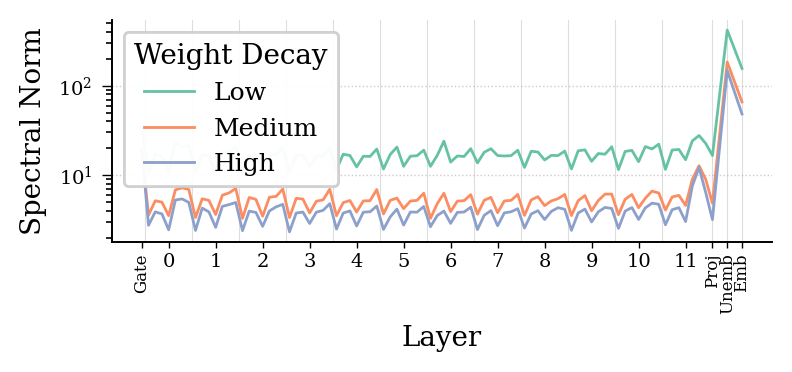

In [11]:
# ── Per-layer spectral norm, layer names on x-axis colored by module group ──
import re
from matplotlib.lines import Line2D

# When True, group all modules belonging to the same transformer block under a
# single x-tick showing only the layer (block) number, instead of one tick per
# individual module. Non-block modules (Embedding, proj, LM Head, ...) keep
# their own label. Set to False to fall back to the per-module labels.
GROUP_BY_LAYER_NUM = True

# Legend label + draw order, mirroring the grad-norm plot.
LABELS = {"low": "Low", "medium": "Medium", "high": "High"}
ORDER  = [k for k in ["low", "medium", "high"] if k in all_dfs]

def _natkey(s):
    # natural sort: "transformer.h.2" < "transformer.h.10"
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", s)]

def layer_group(name):
    n = name.lower()
    if "lm_head" in n:                      return "LM Head"
    if "wte" in n or "embed" in n:          return "Embedding"
    # MLP first so SwiGLU gate_proj/up_proj/down_proj all share the MLP color
    if "mlp" in n or "c_fc" in n or "fc" in n: return "MLP"
    if "attn" in n or "attention" in n:     return "Attention"
    if "gate" in n:                         return "Gate"
    if "ws" in n:                           return "WS"
    if "mtp" in n:                          return "MTP"
    return "Other"

def group_key(name):
    # Modules within the same transformer block share a key -> one x-tick.
    # Non-block modules each keep their own (edited) name as the label.
    m = re.search(r"gpt2_blocks\.(\d+)", name)
    if m:
        return ("block", int(m.group(1)))
    return ("special", edit_layer_name(name))

# Common layer ordering (forward-ish) shared across all runs.
ref_layers = sorted(all_dfs[ORDER[0]]["layer"].tolist(), key=_natkey)
groups = [layer_group(l) for l in ref_layers]

# Stable color per group.
uniq_groups = sorted(set(groups), key=lambda g: groups.index(g))
gcolors = {g: plt.cm.tab20.colors[(i+5) % 10] for i, g in enumerate(uniq_groups)}

# ── Build grouped x-ticks AND a per-module display-x mapping ─────────────────
# Each tick spans a contiguous run of modules (tick_members). The trailing
# special modules are fanned out to a wider spacing so their vertical labels
# don't collide; the SAME mapping (xpos) is used to plot the data, so the line
# stays aligned with both its ticks and its grid lines.
SPECIAL_ABBR = {"gate": "Gate", "embed.": "Emb", "lm_head": "Unemb"}
def _abbr(lbl):
    return SPECIAL_ABBR.get(lbl, lbl.replace("proj.", "Proj").rstrip("."))

keys = [group_key(l) for l in ref_layers]
tick_pos, tick_lab, tick_kind, tick_members = [], [], [], []
seps = []          # (raw_boundary_pos, idx_of_tick_to_its_left)
start = 0
for j in range(1, len(keys) + 1):
    if j == len(keys) or keys[j] != keys[start]:
        tick_pos.append((start + j - 1) / 2.0)
        kind, val = keys[start]
        tick_lab.append(str(val) if kind == "block" else _abbr(val))
        tick_kind.append(keys[start])
        tick_members.append((start, j - 1))
        if j < len(keys):
            seps.append((j - 0.5, len(tick_pos) - 1))
        start = j

# Per-module display x (defaults to the natural ordering position).
xpos = np.arange(len(ref_layers), dtype=float)

SPECIAL_GAP = 2.2
spread_from = len(tick_kind)
while spread_from > 0 and tick_kind[spread_from - 1][0] == "special":
    spread_from -= 1
spread_applied = 0 < spread_from < len(tick_pos)
if spread_applied:
    base = tick_pos[spread_from]
    for off, idx in enumerate(range(spread_from, len(tick_pos))):
        new = base + off * SPECIAL_GAP
        tick_pos[idx] = new
        s_i, e_i = tick_members[idx]      # special groups are single modules
        xpos[s_i:e_i + 1] = new

# fig, ax = plt.subplots(figsize=(max(6, len(ref_layers) * 0.13), 4))
fig, ax = plt.subplots(figsize=(4, 1.9))

for i, key in enumerate(ORDER):
    s = all_dfs[key].set_index("layer")["spectral_norm"].reindex(ref_layers)
    ax.plot(
        xpos, s.values,
        label=LABELS.get(key, key.title()),
        color=COLORS_RUNS[i],
        linestyle=LINESTYLES[i % len(LINESTYLES)],
        zorder=3,
    )

if spread_applied:
    ax.set_xlim(right=max(tick_pos[-1] + 0.8, ax.get_xlim()[1]))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#aaaaaa")
ax.set_axisbelow(True)

ax.set_yscale("log")

if GROUP_BY_LAYER_NUM:
    # Grid/separator lines:
    #   * block region -> faint line between groups (unchanged).
    #   * fanned-out specials -> one faint line straight THROUGH each spread
    #     tick so every label has a grid line directly beneath it.
    for raw_pos, left_idx in seps:
        if spread_applied and left_idx >= spread_from - 1:
            continue
        ax.axvline(raw_pos, color="#dddddd", linewidth=0.4, zorder=0)
    if spread_applied:
        for idx in range(spread_from, len(tick_pos)):
            ax.axvline(tick_pos[idx], color="#dddddd", linewidth=0.4, zorder=0)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lab)
    # Per-tick styling: numbers stay flat & black; words go vertical, smaller,
    # and take their module-group color so neighbours don't blur together.
    for lab, (kind, val) in zip(ax.get_xticklabels(), tick_kind):
        if kind == "block":
            lab.set_rotation(0)
            lab.set_fontsize(7)
        else:
            lab.set_rotation(90)
            lab.set_fontsize(6)
            lab.set_va("top")
            # lab.set_color(gcolors.get(layer_group(val), "#000000"))
    ax.tick_params(axis="x", length=2, pad=2)
    ax.set_xlabel("Layer", fontsize=10)
else:
    # Layer names on the x-axis, each tick label colored by its group.
    ax.set_xticks(xpos)
    ax.set_xticklabels([edit_layer_name(rl) for rl in ref_layers], rotation=90, fontsize=7)
    for tick, g in zip(ax.get_xticklabels(), groups):
        tick.set_color(gcolors[g])

ax.set_ylabel("Spectral Norm", fontsize=10)
# ax.set_title("Per-Layer Spectral Norm ($k=9$)", fontsize=12)

# Two legends: WD (lines) + module group (tick colors).
wd_leg = ax.legend(title="Weight Decay", frameon=True, framealpha=0.8,
                   edgecolor="#cccccc", loc="upper left", fontsize=9, title_fontsize=10)
ax.add_artist(wd_leg)
group_handles = [Line2D([0], [0], marker="s", linestyle="", color=gcolors[g],
                        markersize=5, label=g) for g in uniq_groups]
# ax.legend(handles=group_handles, title="Module group", frameon=True,
        #   framealpha=0.8, edgecolor="#cccccc", loc="upper left", fontsize=6)

fig.tight_layout()
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/spectral_norm_layers.pdf")
plt.show()


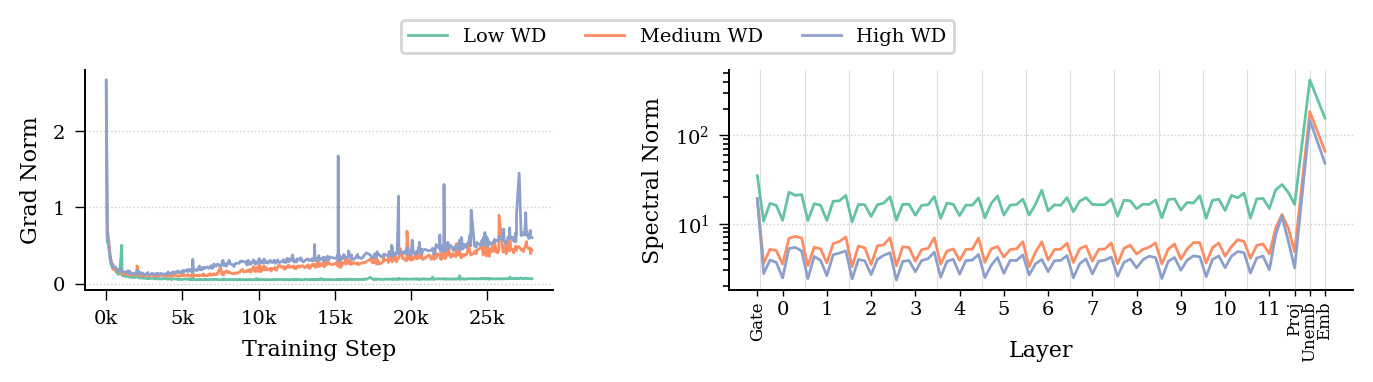

In [16]:
# ── Combined figure: grad norm (left) + per-layer spectral norm (right) ──────
# Single global legend (Weight Decay) sitting outside, top-center.
import re
import numpy as np
import matplotlib.ticker as ticker

SMOOTH = 1

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(7, 1.7), gridspec_kw={"width_ratios": [3, 4]}
)

# ── Left panel: train grad norm last ────────────────────────────────────────
for i, (run_id, label) in enumerate(RUNS.items()):
    h     = histories[run_id]
    vals  = h[METRIC].dropna()
    steps = h.loc[vals.index, STEP_COL]
    y     = vals.rolling(SMOOTH, min_periods=1).mean() if SMOOTH > 1 else vals
    axL.plot(
        steps, y.values,
        label=label,
        color=COLORS_RUNS[i],
        linestyle=LINESTYLES[i % len(LINESTYLES)],
    )

axL.spines["top"].set_visible(False)
axL.spines["right"].set_visible(False)
axL.yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#aaaaaa")
axL.set_axisbelow(True)
axL.set_xlabel("Training Step")
axL.set_ylabel("Grad Norm")
axL.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x / 1000)}k"))

# ── Right panel: per-layer spectral norm ────────────────────────────────────
LABELS = {"low": "Low", "medium": "Medium", "high": "High"}
ORDER  = [k for k in ["low", "medium", "high"] if k in all_dfs]

def _natkey(s):
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", s)]

def group_key(name):
    m = re.search(r"gpt2_blocks\.(\d+)", name)
    if m:
        return ("block", int(m.group(1)))
    return ("special", edit_layer_name(name))

ref_layers = sorted(all_dfs[ORDER[0]]["layer"].tolist(), key=_natkey)

SPECIAL_ABBR = {"gate": "Gate", "embed.": "Emb", "lm_head": "Unemb"}
def _abbr(lbl):
    return SPECIAL_ABBR.get(lbl, lbl.replace("proj.", "Proj").rstrip("."))

keys = [group_key(l) for l in ref_layers]
tick_pos, tick_lab, tick_kind, tick_members = [], [], [], []
seps = []
start = 0
for j in range(1, len(keys) + 1):
    if j == len(keys) or keys[j] != keys[start]:
        tick_pos.append((start + j - 1) / 2.0)
        kind, val = keys[start]
        tick_lab.append(str(val) if kind == "block" else _abbr(val))
        tick_kind.append(keys[start])
        tick_members.append((start, j - 1))
        if j < len(keys):
            seps.append((j - 0.5, len(tick_pos) - 1))
        start = j

xpos = np.arange(len(ref_layers), dtype=float)
SPECIAL_GAP = 2.4
spread_from = len(tick_kind)
while spread_from > 0 and tick_kind[spread_from - 1][0] == "special":
    spread_from -= 1
spread_applied = 0 < spread_from < len(tick_pos)
if spread_applied:
    base = tick_pos[spread_from]
    for off, idx in enumerate(range(spread_from, len(tick_pos))):
        new = base + off * SPECIAL_GAP
        tick_pos[idx] = new
        s_i, e_i = tick_members[idx]
        xpos[s_i:e_i + 1] = new

for i, key in enumerate(ORDER):
    s = all_dfs[key].set_index("layer")["spectral_norm"].reindex(ref_layers)
    axR.plot(
        xpos, s.values,
        label=LABELS.get(key, key.title()),
        color=COLORS_RUNS[i],
        linestyle=LINESTYLES[i % len(LINESTYLES)],
        zorder=3,
    )

if spread_applied:
    axR.set_xlim(right=max(tick_pos[-1] + 0.8, axR.get_xlim()[1]))

axR.spines["top"].set_visible(False)
axR.spines["right"].set_visible(False)
axR.yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#aaaaaa")
axR.set_axisbelow(True)
axR.set_yscale("log")

for raw_pos, left_idx in seps:
    if spread_applied and left_idx >= spread_from - 1:
        continue
    axR.axvline(raw_pos, color="#dddddd", linewidth=0.4, zorder=0)
if spread_applied:
    for idx in range(spread_from, len(tick_pos)):
        axR.axvline(tick_pos[idx], color="#dddddd", linewidth=0.4, zorder=0)

axR.set_xticks(tick_pos)
axR.set_xticklabels(tick_lab)
for lab, (kind, val) in zip(axR.get_xticklabels(), tick_kind):
    if kind == "block":
        lab.set_rotation(0)
        lab.set_fontsize(7)
    else:
        lab.set_rotation(90)
        lab.set_fontsize(6)
        lab.set_va("top")
axR.tick_params(axis="x", length=2, pad=2)
axR.set_xlabel("Layer", labelpad=-8)
axR.set_ylabel("Spectral Norm")

# ── Global legend outside, top-center ───────────────────────────────────────
handles, labels = axL.get_legend_handles_labels()
labels = [l + " WD" for l in labels]
fig.legend(
    handles, labels,
    # title="Weight Decay",
    ncol=len(labels),
    frameon=True, framealpha=0.8, edgecolor="#cccccc",
    loc="lower center", bbox_to_anchor=(0.5, 0.95),
)

fig.tight_layout(w_pad=4)
Path("./plots").mkdir(exist_ok=True)
fig.savefig("./plots/grad_norm_and_spectral_norm.pdf", bbox_inches="tight")
plt.show()
